# Iowa Liquor Sales: ML Forecasting & Segmentation
## SARIMA, Prophet & K-Means with BigQuery

Machine learning models for sales forecasting and store segmentation using the Iowa Liquor Sales public dataset.

**Dataset**: `bigquery-public-data.iowa_liquor_sales.sales` (~33.6M rows, 2012-present)

### Contents:
1. Setup & BigQuery Connection
2. Time Series Decomposition
3. SARIMA Forecasting
4. K-Means Store Segmentation
5. Standard Deviation (Step by Step)
6. Facebook Prophet Forecasting
7. Model Comparison (SARIMA vs Prophet)
8. RMSE Validation

---
## Setup & BigQuery Connection

In [1]:
import pandas as pd
import numpy as np
import os
from google.cloud import bigquery
from google.oauth2 import service_account

pd.options.display.float_format = '{:,.2f}'.format
pd.options.styler.format.formatter = '{:,}'.format

credentials = service_account.Credentials.from_service_account_file('../service_account_iowa.json')
client = bigquery.Client(credentials=credentials, project=credentials.project_id)

def run_sql(file):
    with open(f'../sql_queries/{file}') as f:
        return client.query(f.read()).to_dataframe()

def run_query(sql):
    return client.query(sql).to_dataframe()

---
## 10. Time Series Fundamentals: The 3 Components

Every time series can be decomposed into three components:

1. **Trend**: The long-term direction (increasing, decreasing, or flat)
2. **Seasonality**: Repeating patterns at fixed intervals (weekly, monthly, yearly)
3. **Residual (Noise)**: The random variation left after removing trend and seasonality

**Decomposition types**:
- **Additive**: `Y = Trend + Seasonality + Residual` (when seasonal variation is constant)
- **Multiplicative**: `Y = Trend x Seasonality x Residual` (when seasonal variation scales with the level)


In [58]:
import matplotlib.pyplot as plt

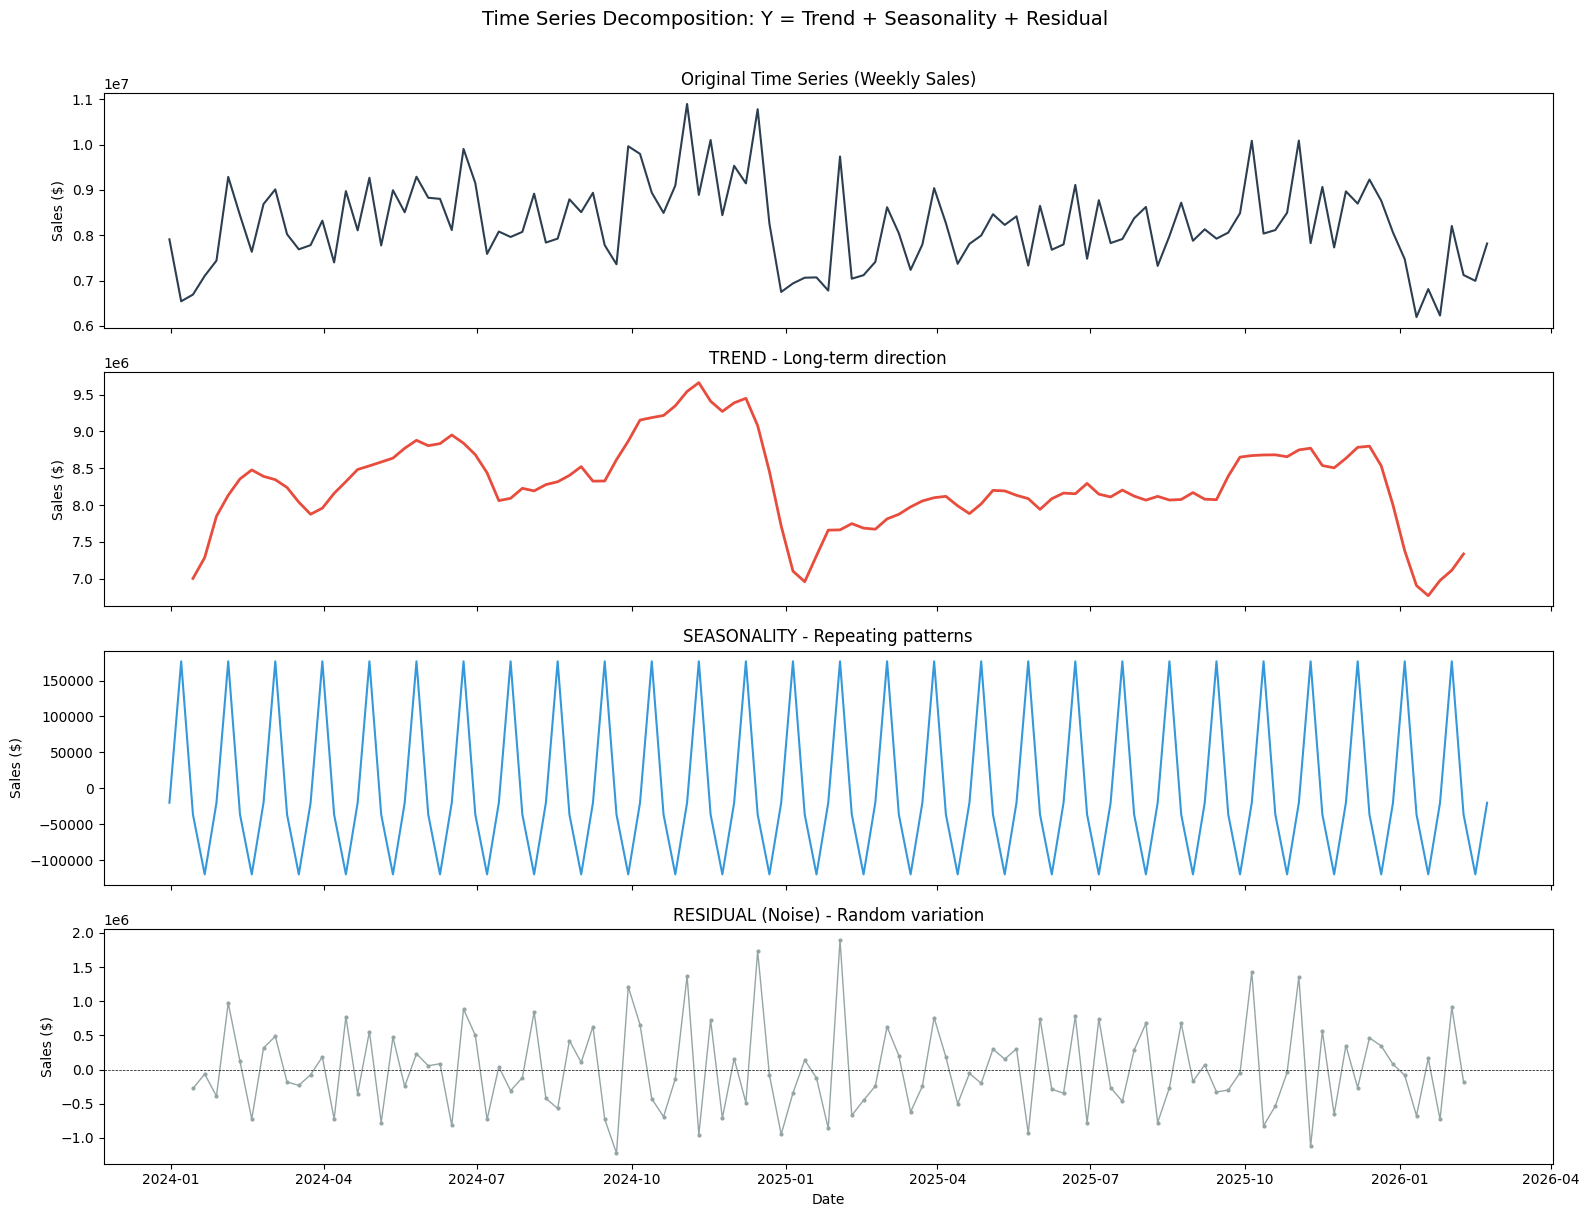

Decomposition complete.
  Trend range: $6,768,852 to $9,663,194
  Seasonal amplitude: +/- $176,832
  Residual std: $634,298 (lower = better model fit)


In [59]:
# Time Series Decomposition - visualize Trend, Seasonality, Residual
from statsmodels.tsa.seasonal import seasonal_decompose

# We need the weekly data first - pull it here so it's available
# (will be reused by SARIMA and Prophet sections below)
ts_decomp_df = run_query("""
    SELECT
        DATE_TRUNC(date, WEEK) AS sale_week,
        ROUND(SUM(sale_dollars), 2) AS total_sales
    FROM `bigquery-public-data.iowa_liquor_sales.sales`
    WHERE date >= '2024-01-01'
    GROUP BY sale_week
    ORDER BY sale_week
""")
ts_decomp_df['sale_week'] = pd.to_datetime(ts_decomp_df['sale_week'])
ts_decomp_df.set_index('sale_week', inplace=True)
ts_decomp = ts_decomp_df['total_sales']

# Additive decomposition (period=4 for ~monthly pattern in weekly data)
decomposition = seasonal_decompose(ts_decomp, model='additive', period=4)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# Original
axes[0].plot(ts_decomp, color='#2c3e50', linewidth=1.5)
axes[0].set_title('Original Time Series (Weekly Sales)', fontsize=12)
axes[0].set_ylabel('Sales ($)')

# Trend
axes[1].plot(decomposition.trend, color='#e74c3c', linewidth=2)
axes[1].set_title('TREND - Long-term direction', fontsize=12)
axes[1].set_ylabel('Sales ($)')

# Seasonality
axes[2].plot(decomposition.seasonal, color='#3498db', linewidth=1.5)
axes[2].set_title('SEASONALITY - Repeating patterns', fontsize=12)
axes[2].set_ylabel('Sales ($)')

# Residual
axes[3].plot(decomposition.resid, color='#95a5a6', linewidth=1, marker='o', markersize=2)
axes[3].axhline(y=0, color='black', linewidth=0.5, linestyle='--')
axes[3].set_title('RESIDUAL (Noise) - Random variation', fontsize=12)
axes[3].set_ylabel('Sales ($)')
axes[3].set_xlabel('Date')

plt.suptitle('Time Series Decomposition: Y = Trend + Seasonality + Residual', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("Decomposition complete.")
print(f"  Trend range: ${decomposition.trend.min():,.0f} to ${decomposition.trend.max():,.0f}")
print(f"  Seasonal amplitude: +/- ${decomposition.seasonal.max():,.0f}")
print(f"  Residual std: ${decomposition.resid.std():,.0f} (lower = better model fit)")

---
## 11. SARIMA Forecasting

Using the BigQuery data to build a time series forecast.

- SARIMA handles trend + seasonality
- (p,d,q) = AR order, differencing, MA order
- (P,D,Q,m) = seasonal components
- Weekly aggregation reduces noise


In [60]:
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [61]:
# Pull weekly aggregated sales from BigQuery
weekly_sales_df = run_query("""
    SELECT
        DATE_TRUNC(date, WEEK) AS sale_week,
        ROUND(SUM(sale_dollars), 2) AS total_sales,
        SUM(bottles_sold) AS total_bottles,
        COUNT(*) AS num_transactions
    FROM `bigquery-public-data.iowa_liquor_sales.sales`
    WHERE date >= '2024-01-01'
    GROUP BY sale_week
    ORDER BY sale_week
""")
weekly_sales_df['sale_week'] = pd.to_datetime(weekly_sales_df['sale_week'])
weekly_sales_df.set_index('sale_week', inplace=True)
weekly_sales_df.head()

,total_sales,total_bottles,num_transactions
sale_week,,,
2023-12-31,"7,909,589.01",533289,45710
2024-01-07,"6,543,553.71",464946,41622
2024-01-14,"6,690,793.98",504710,45795
2024-01-21,"7,103,371.84",522522,47976
2024-01-28,"7,440,468.85",538868,48375


In [62]:
# Fit SARIMA model
ts = weekly_sales_df['total_sales']

model = SARIMAX(
    ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 52),  # weekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit(disp=False)
print(results.summary().tables[0])

                                      SARIMAX Results                                      
Dep. Variable:                         total_sales   No. Observations:                  113
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 52)   Log Likelihood                -102.778
Date:                             Sat, 28 Mar 2026   AIC                            213.557
Time:                                     20:44:14   BIC                            213.340
Sample:                                 12-31-2023   HQIC                           210.883
                                      - 02-22-2026                                         
Covariance Type:                               opg                                         


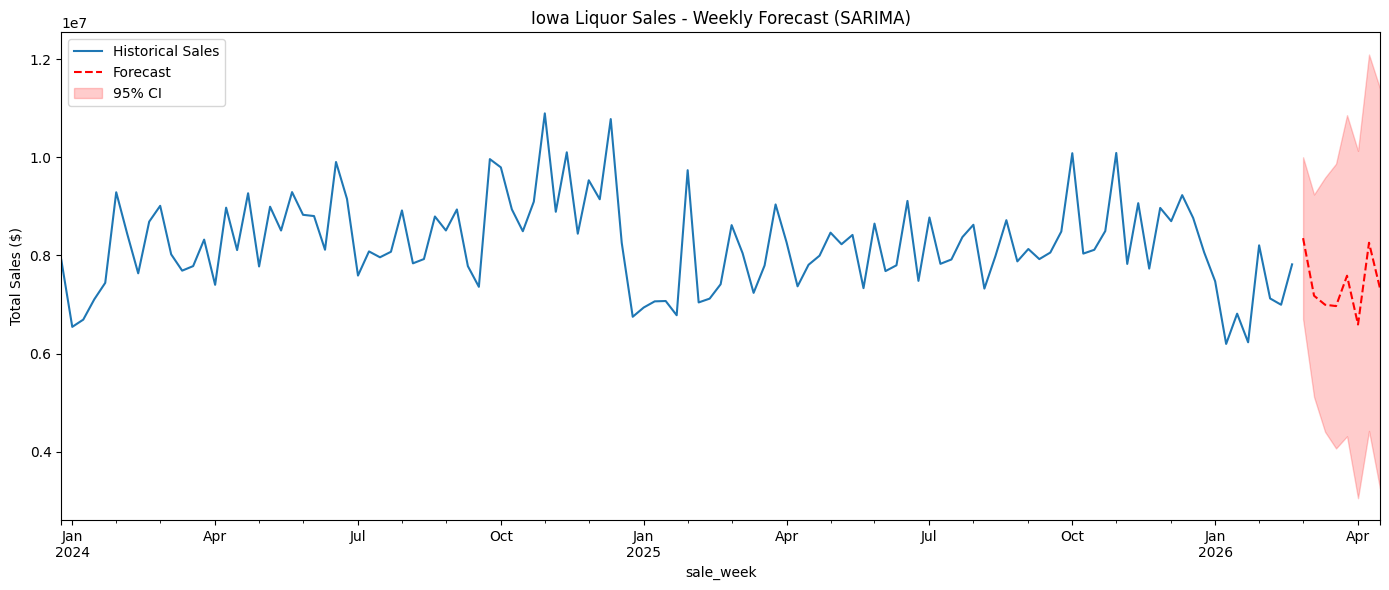


Forecast Summary:


,Forecast,Lower CI,Upper CI
2026-03-01,"8,351,464.27","6,703,297.26","9,999,631.28"
2026-03-08,"7,177,889.81","5,114,524.77","9,241,254.85"
2026-03-15,"6,994,684.54","4,405,067.99","9,584,301.10"
2026-03-22,"6,967,189.43","4,066,143.05","9,868,235.82"
2026-03-29,"7,585,904.23","4,314,425.61","10,857,382.85"
2026-04-05,"6,590,895.09","3,051,988.96","10,129,801.22"
2026-04-12,"8,258,098.30","4,422,641.87","12,093,554.72"
2026-04-19,"7,328,211.31","3,253,386.19","11,403,036.42"


In [63]:
# Forecast next 8 weeks
forecast_steps = 8
forecast = results.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ts.plot(ax=ax, label='Historical Sales')
forecast_mean.plot(ax=ax, label='Forecast', color='red', linestyle='--')
ax.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2, color='red', label='95% CI'
)
ax.set_title('Iowa Liquor Sales - Weekly Forecast (SARIMA)')
ax.set_ylabel('Total Sales ($)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nForecast Summary:')
forecast_summary = pd.DataFrame({
    'Forecast': forecast_mean.round(2),
    'Lower CI': forecast_ci.iloc[:, 0].round(2),
    'Upper CI': forecast_ci.iloc[:, 1].round(2)
})
forecast_summary

---
## 12. K-Means Store Segmentation

- K-Means groups similar stores based on sales behavior
- Log-transform handles skewed retail data
- Business value: different strategies for High/Mid/Low volume stores

In [64]:
# Pull store-level aggregations from BigQuery
store_df = run_query("""
    SELECT
        store_number,
        store_name,
        city,
        ROUND(SUM(sale_dollars), 2) AS total_sales,
        SUM(bottles_sold) AS total_bottles,
        COUNT(*) AS num_transactions,
        COUNT(DISTINCT item_description) AS unique_products,
        ROUND(AVG(sale_dollars), 2) AS avg_transaction
    FROM `bigquery-public-data.iowa_liquor_sales.sales`
    WHERE date >= '2024-07-01'
    GROUP BY store_number, store_name, city
    HAVING COUNT(*) >= 10
""")
print(f'Stores to segment: {len(store_df)}')
store_df.head()

Stores to segment: 2436


,store_number,store_name,city,total_sales,total_bottles,num_transactions,unique_products,avg_transaction
0,4161,FAREWAY STORES #950 / IOWA CITY,IOWA CITY,"310,111.13",19292,2022,297,153.37
1,2502,HY-VEE WINE AND SPIRITS (1022) / ANKENY,ANKENY,"3,315,995.42",183660,13691,1709,242.20
2,5234,CASEY'S GENERAL STORE #3473 / DUBUQU,DUBUQUE,"107,003.25",15620,512,132,208.99
3,4487,CASEY'S GENERAL STORE #2787 / CEDAR RAPIDS,CEDAR RAPIDS,"289,135.18",43187,1872,221,154.45
4,10585,HOMETOWN LIQUOR & WINE / MOUNT PLEASANT,MOUNT PLEASANT,"324,352.72",15585,2155,1243,150.51


In [65]:
# Prepare features for clustering
features = ['total_sales', 'total_bottles', 'num_transactions']
X = store_df[features].copy()
X_log = np.log1p(X)  # Log transform to handle skewness

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
store_df['cluster'] = kmeans.fit_predict(X_scaled)

# Label clusters by sales volume
cluster_means = store_df.groupby('cluster')['total_sales'].mean().sort_values(ascending=False)
label_map = {cluster_means.index[0]: 'High-Hub', cluster_means.index[1]: 'Mid-Hub', cluster_means.index[2]: 'Low-Hub'}
store_df['segment'] = store_df['cluster'].map(label_map)

# Summary
print('\nSegment Summary:')
store_df.groupby('segment').agg({
    'store_number': 'count',
    'total_sales': ['mean', 'sum'],
    'total_bottles': 'mean',
    'num_transactions': 'mean'
}).round(2)


Segment Summary:


store_number total_sales                total_bottles  \
                count        mean            sum          mean   
segment                                                          
High-Hub          660  866,509.09 571,895,999.58     56,196.09   
Low-Hub           435   17,774.64   7,731,968.37      1,521.73   
Mid-Hub          1341  101,741.03 136,434,722.78      9,815.67   

         num_transactions  
                     mean  
segment                    
High-Hub         4,339.53  
Low-Hub            157.41  
Mid-Hub            922.74

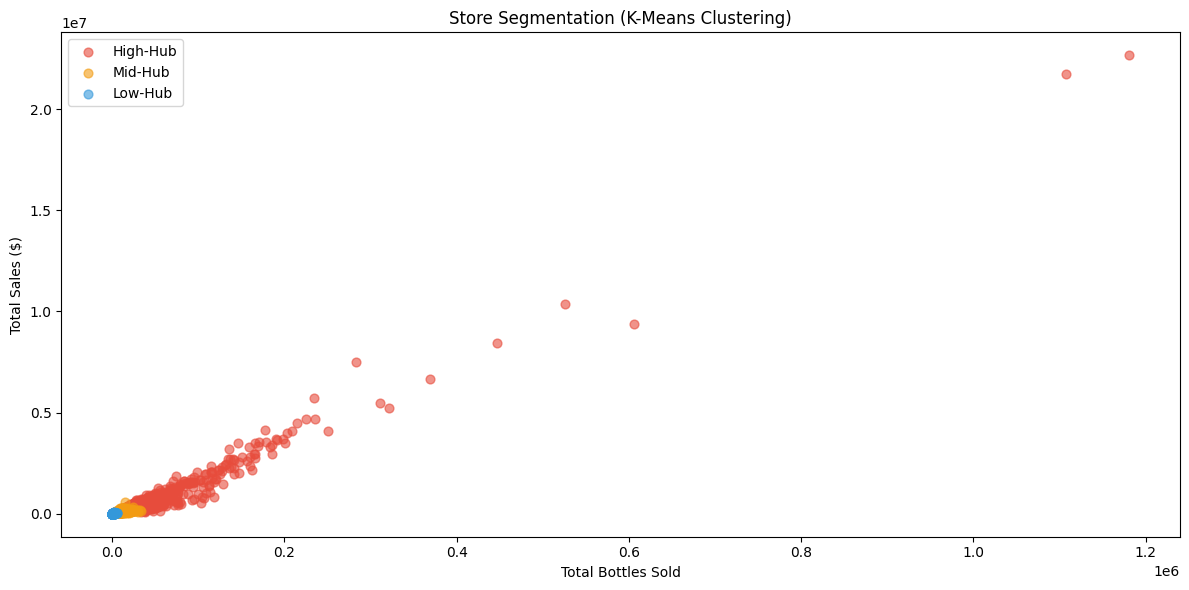

In [66]:
# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
colors = {'High-Hub': '#e74c3c', 'Mid-Hub': '#f39c12', 'Low-Hub': '#3498db'}

for segment, color in colors.items():
    mask = store_df['segment'] == segment
    ax.scatter(
        store_df.loc[mask, 'total_bottles'],
        store_df.loc[mask, 'total_sales'],
        c=color, label=segment, alpha=0.6, s=40
    )

ax.set_xlabel('Total Bottles Sold')
ax.set_ylabel('Total Sales ($)')
ax.set_title('Store Segmentation (K-Means Clustering)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 13. Standard Deviation: Manual Calculation (Step by Step)

Understanding the math behind `std()`.

**Formula**: $\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x})^2}$

**Steps**:
1. Calculate the **mean** ($\bar{x}$)
2. Find the **deviation** from the mean for each value ($x_i - \bar{x}$)
3. **Square** each deviation ($(x_i - \bar{x})^2$)
4. Calculate the **variance** (average of squared deviations)
5. Take the **square root** of the variance = Standard Deviation


In [67]:
# Manual Standard Deviation - Step by Step using monthly sales data
monthly_sales = run_query("""
    SELECT
        DATE_TRUNC(date, MONTH) AS sale_month,
        ROUND(SUM(sale_dollars), 2) AS total_sales
    FROM `bigquery-public-data.iowa_liquor_sales.sales`
    WHERE date >= '2024-07-01'
    GROUP BY sale_month
    ORDER BY sale_month
""")

values = monthly_sales['total_sales'].values
n = len(values)
print(f"Our data: {n} monthly sales values")
print(f"Values: {values}\n")

# Step 1: Calculate the MEAN
mean = sum(values) / n
print(f"Step 1 - Mean (xÌ„): {mean:,.2f}")
print(f"  Formula: sum(all values) / N = {sum(values):,.2f} / {n}\n")

# Step 2: Find DEVIATIONS from the mean (xi - xÌ„)
deviations = values - mean
print(f"Step 2 - Deviations (xi - xÌ„):")
for i, (val, dev) in enumerate(zip(values, deviations)):
    print(f"  Month {i+1}: {val:>14,.2f} - {mean:>14,.2f} = {dev:>14,.2f}")

# Step 3: SQUARE each deviation
squared_deviations = deviations ** 2
print(f"\nStep 3 - Squared deviations (xi - xÌ„)Â²:")
for i, (dev, sq) in enumerate(zip(deviations, squared_deviations)):
    print(f"  Month {i+1}: ({dev:>14,.2f})Â² = {sq:>20,.2f}")

# Step 4: Calculate VARIANCE (average of squared deviations)
# Population variance (ddof=0): divide by N
# Sample variance (ddof=1): divide by N-1
variance_pop = sum(squared_deviations) / n
variance_sample = sum(squared_deviations) / (n - 1)
print(f"\nStep 4 - Variance:")
print(f"  Sum of squared deviations: {sum(squared_deviations):,.2f}")
print(f"  Population variance (Ã·N):   {variance_pop:,.2f}")
print(f"  Sample variance (Ã·(N-1)):   {variance_sample:,.2f}")

# Step 5: SQUARE ROOT = Standard Deviation
std_pop = variance_pop ** 0.5
std_sample = variance_sample ** 0.5
print(f"\nStep 5 - Standard Deviation (âˆšvariance):")
print(f"  Population std: {std_pop:,.2f}")
print(f"  Sample std:     {std_sample:,.2f}")

# Verify with numpy/pandas
print(f"\n--- Verification with Python functions ---")
print(f"  np.std(values, ddof=0): {np.std(values, ddof=0):,.2f}  (matches population)")
print(f"  np.std(values, ddof=1): {np.std(values, ddof=1):,.2f}  (matches sample)")
print(f"  pd.Series(values).std(): {pd.Series(values).std():,.2f}  (pandas defaults to ddof=1)")

Our data: 20 monthly sales values
Values: [37563557.73 36529981.19 34410490.22 42691915.2  40090042.22 41196967.68
 31111677.66 31308695.75 33518798.61 35499986.35 35589683.49 35946281.01
 36094242.39 34213226.46 35157772.73 40047135.7  34754507.22 41751430.27
 28627693.65 30138437.41]

Step 1 - Mean (xÌ„): 35,812,126.15
  Formula: sum(all values) / N = 716,242,522.94 / 20

Step 2 - Deviations (xi - xÌ„):
  Month 1:  37,563,557.73 -  35,812,126.15 =   1,751,431.58
  Month 2:  36,529,981.19 -  35,812,126.15 =     717,855.04
  Month 3:  34,410,490.22 -  35,812,126.15 =  -1,401,635.93
  Month 4:  42,691,915.20 -  35,812,126.15 =   6,879,789.05
  Month 5:  40,090,042.22 -  35,812,126.15 =   4,277,916.07
  Month 6:  41,196,967.68 -  35,812,126.15 =   5,384,841.53
  Month 7:  31,111,677.66 -  35,812,126.15 =  -4,700,448.49
  Month 8:  31,308,695.75 -  35,812,126.15 =  -4,503,430.40
  Month 9:  33,518,798.61 -  35,812,126.15 =  -2,293,327.54
  Month 10:  35,499,986.35 -  35,812,126.15 =    -3

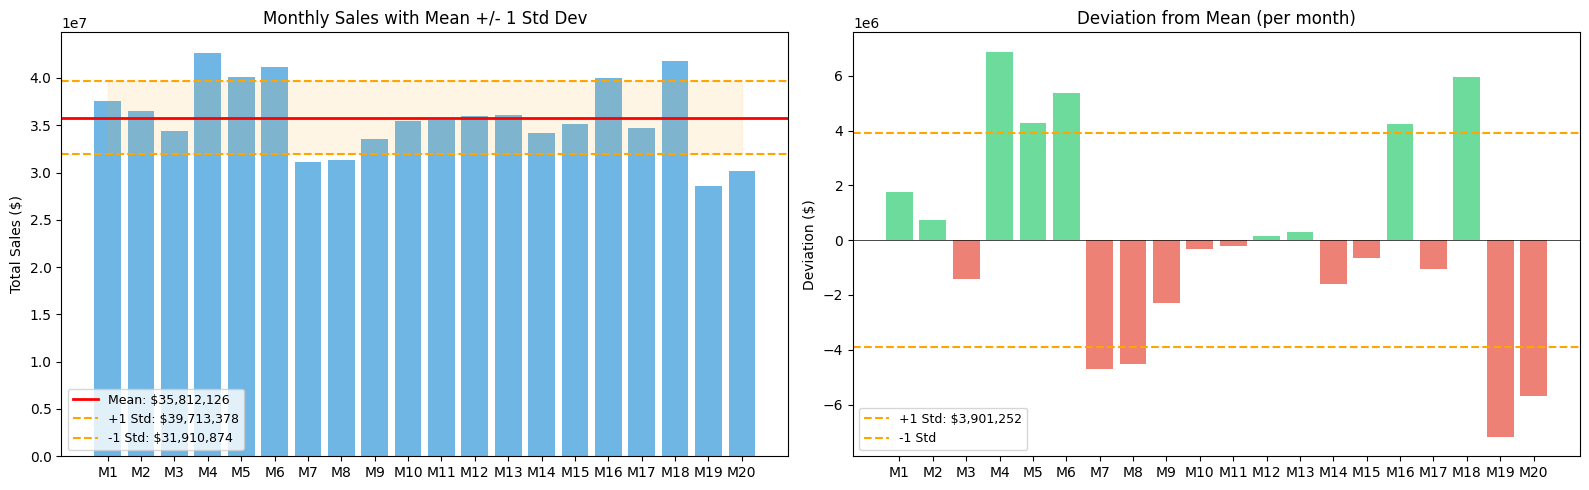

In [68]:
# Visualize the standard deviation concept
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

months = [f"M{i+1}" for i in range(n)]

# Left: Bar chart with mean line and std bands
ax1 = axes[0]
ax1.bar(months, values, color='#3498db', alpha=0.7)
ax1.axhline(y=mean, color='red', linestyle='-', linewidth=2, label=f'Mean: ${mean:,.0f}')
ax1.axhline(y=mean + std_sample, color='orange', linestyle='--', label=f'+1 Std: ${mean + std_sample:,.0f}')
ax1.axhline(y=mean - std_sample, color='orange', linestyle='--', label=f'-1 Std: ${mean - std_sample:,.0f}')
ax1.fill_between(range(n), mean - std_sample, mean + std_sample, alpha=0.1, color='orange')
ax1.set_title('Monthly Sales with Mean +/- 1 Std Dev')
ax1.set_ylabel('Total Sales ($)')
ax1.legend(fontsize=9)

# Right: Deviation from mean
colors_dev = ['#e74c3c' if d < 0 else '#2ecc71' for d in deviations]
ax2 = axes[1]
ax2.bar(months, deviations, color=colors_dev, alpha=0.7)
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.axhline(y=std_sample, color='orange', linestyle='--', label=f'+1 Std: ${std_sample:,.0f}')
ax2.axhline(y=-std_sample, color='orange', linestyle='--', label=f'-1 Std')
ax2.set_title('Deviation from Mean (per month)')
ax2.set_ylabel('Deviation ($)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 13. Facebook Prophet - Forecasting

Prophet is Meta's open-source forecasting library. Great for business time series because:
- Handles **holidays** and **seasonality** automatically
- Robust to **missing data** and **outliers**
- Intuitive parameters (no need to tune p,d,q like SARIMA)



20:48:38 - cmdstanpy - INFO - Chain [1] start processing
20:48:39 - cmdstanpy - INFO - Chain [1] done processing


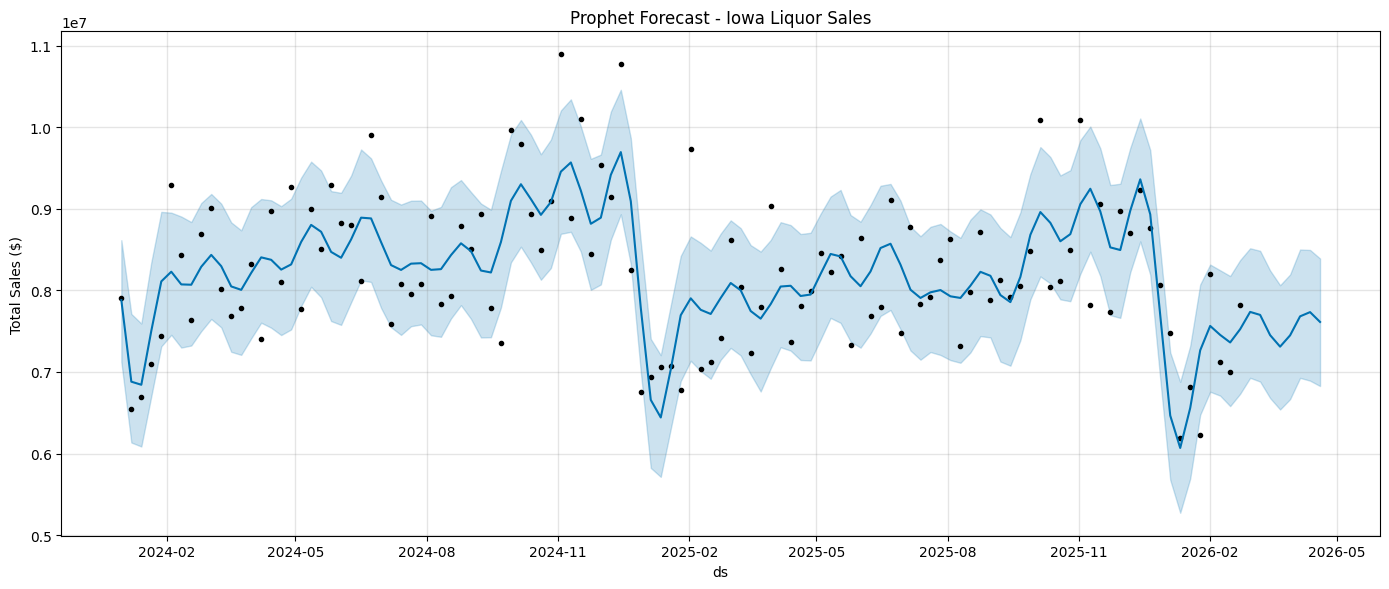

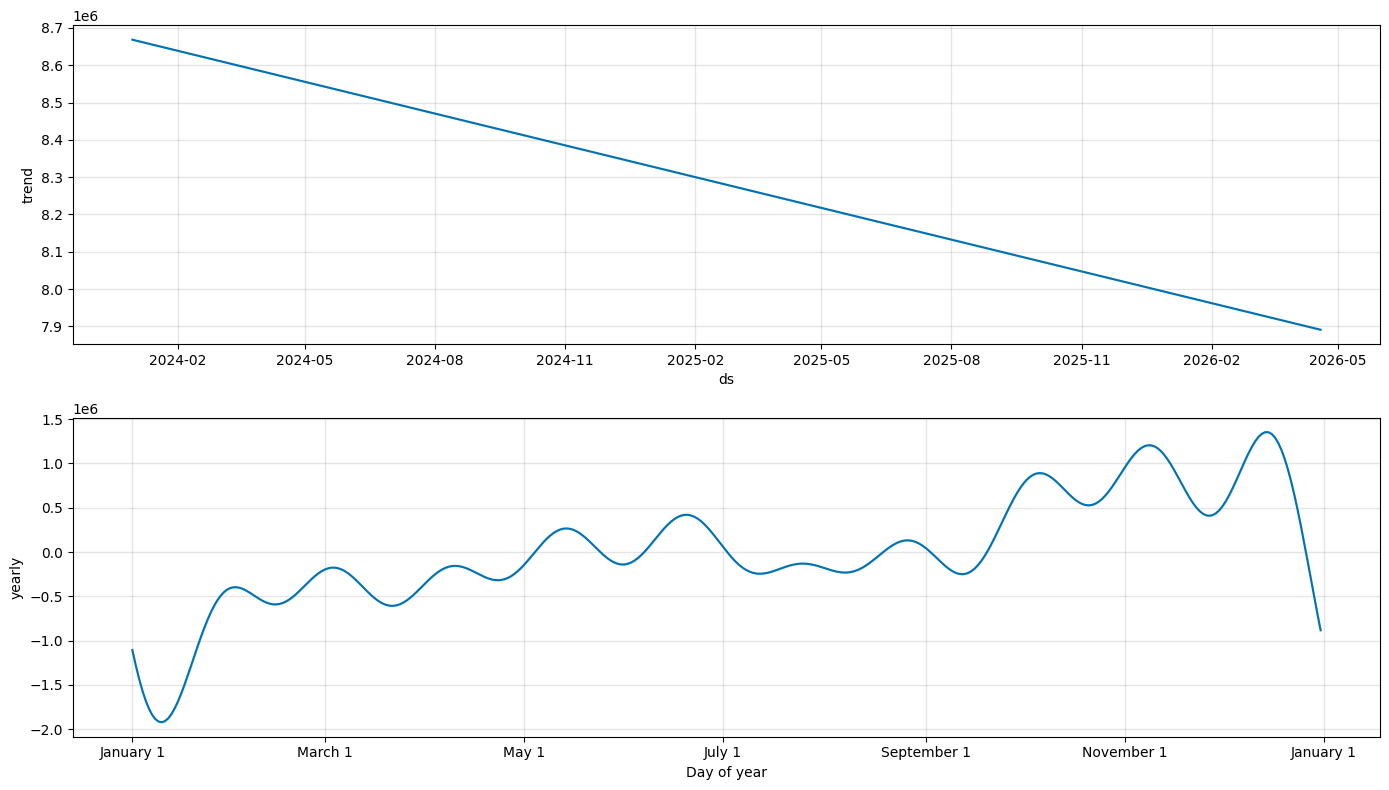


Prophet Forecast (next 8 weeks):


,ds,yhat,yhat_lower,yhat_upper
113,2026-03-01,"7,735,889.57","6,927,912.52","8,515,967.21"
114,2026-03-08,"7,699,153.52","6,881,828.91","8,484,853.87"
115,2026-03-15,"7,451,200.08","6,679,761.02","8,243,434.14"
116,2026-03-22,"7,310,012.67","6,539,652.81","8,063,133.80"
117,2026-03-29,"7,448,598.83","6,666,645.55","8,194,336.72"
118,2026-04-05,"7,681,478.84","6,927,222.11","8,500,773.68"
119,2026-04-12,"7,733,327.89","6,892,913.63","8,495,425.33"
120,2026-04-19,"7,612,584.29","6,827,093.46","8,390,411.78"


In [69]:
# Install prophet if needed: pip install prophet
from prophet import Prophet

# Prophet requires columns named 'ds' (date) and 'y' (value)
prophet_df = weekly_sales_df.reset_index()[['sale_week', 'total_sales']].copy()
prophet_df.columns = ['ds', 'y']
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

# Fit Prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,  # our data is already weekly aggregated
    daily_seasonality=False,
    changepoint_prior_scale=0.05  # controls flexibility (lower = less overfitting)
)
prophet_model.fit(prophet_df)

# Forecast 8 weeks ahead
future = prophet_model.make_future_dataframe(periods=forecast_steps, freq='W')
prophet_forecast = prophet_model.predict(future)

# Plot Prophet's built-in visualization
fig1 = prophet_model.plot(prophet_forecast, figsize=(14, 6))
plt.title('Prophet Forecast - Iowa Liquor Sales')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

# Show components (trend + seasonality)
fig2 = prophet_model.plot_components(prophet_forecast, figsize=(14, 8))
plt.tight_layout()
plt.show()

print('\nProphet Forecast (next 8 weeks):')
prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(forecast_steps)

---
## 14. Model Comparison - SARIMA vs Prophet

Comparing both models side-by-side on the same chart to see which forecast looks more reasonable.



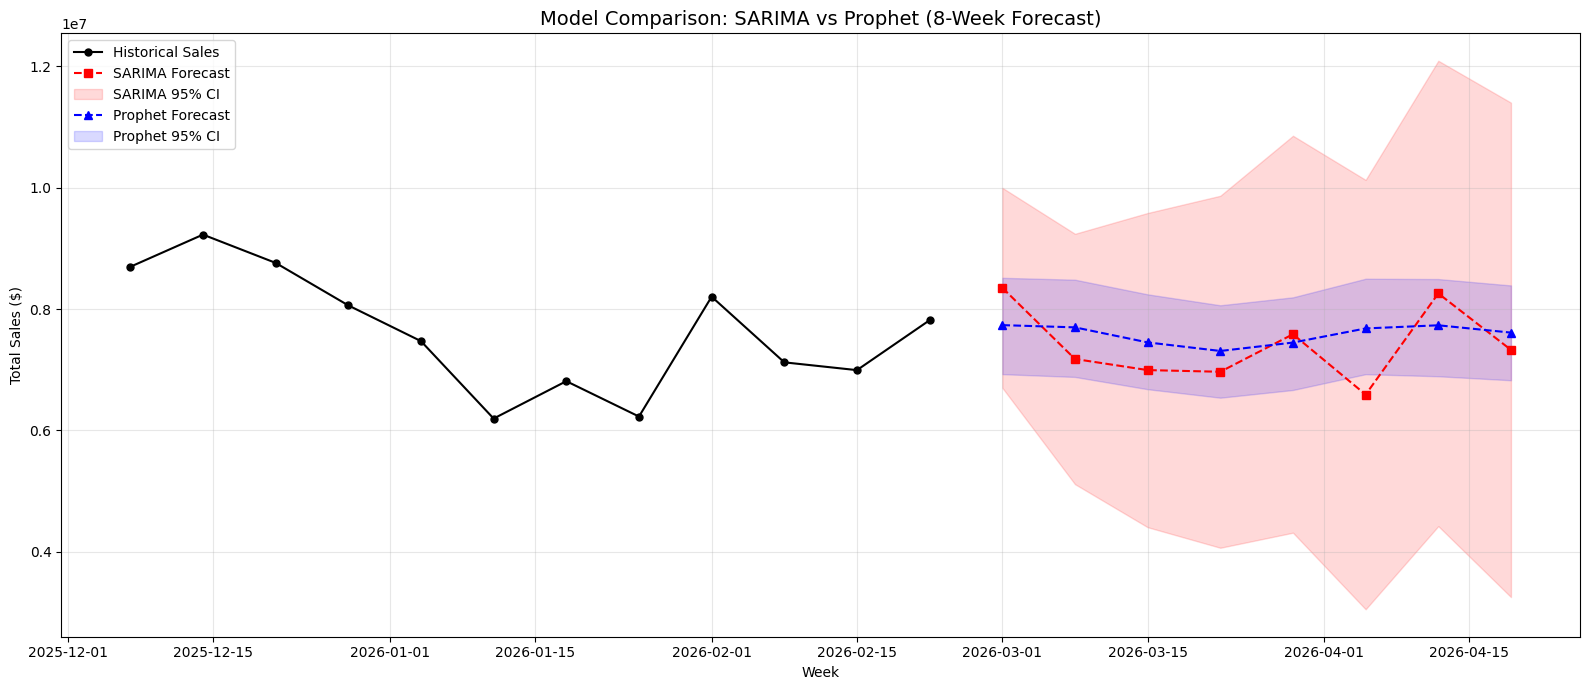


Forecast Comparison Table:


,Week,SARIMA,SARIMA_Lower,SARIMA_Upper,Prophet,Prophet_Lower,Prophet_Upper,Difference,Diff_Pct
0,1,"8,351,464.27","6,703,297.26","9,999,631.28","7,735,889.57","6,927,912.52","8,515,967.21","615,574.70",7.96
1,2,"7,177,889.81","5,114,524.77","9,241,254.85","7,699,153.52","6,881,828.91","8,484,853.87","-521,263.71",-6.77
2,3,"6,994,684.54","4,405,067.99","9,584,301.10","7,451,200.08","6,679,761.02","8,243,434.14","-456,515.54",-6.13
3,4,"6,967,189.43","4,066,143.05","9,868,235.82","7,310,012.67","6,539,652.81","8,063,133.80","-342,823.24",-4.69
4,5,"7,585,904.23","4,314,425.61","10,857,382.85","7,448,598.83","6,666,645.55","8,194,336.72","137,305.40",1.84
5,6,"6,590,895.09","3,051,988.96","10,129,801.22","7,681,478.84","6,927,222.11","8,500,773.68","-1,090,583.75",-14.20
6,7,"8,258,098.30","4,422,641.87","12,093,554.72","7,733,327.89","6,892,913.63","8,495,425.33","524,770.41",6.79
7,8,"7,328,211.31","3,253,386.19","11,403,036.42","7,612,584.29","6,827,093.46","8,390,411.78","-284,372.98",-3.74


In [70]:
# Side-by-side comparison: SARIMA vs Prophet on the same chart
fig, ax = plt.subplots(figsize=(16, 7))

# Historical data (last 12 weeks for cleaner view)
ts_recent = ts.tail(12)
ax.plot(ts_recent.index, ts_recent.values, 'ko-', label='Historical Sales', markersize=5)

# SARIMA forecast
ax.plot(forecast_mean.index, forecast_mean.values, 'rs--', label='SARIMA Forecast', markersize=6)
ax.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.15, color='red', label='SARIMA 95% CI'
)

# Prophet forecast (last 8 rows = forecast period)
prophet_future = prophet_forecast.tail(forecast_steps)
ax.plot(
    pd.to_datetime(prophet_future['ds']),
    prophet_future['yhat'],
    'b^--', label='Prophet Forecast', markersize=6
)
ax.fill_between(
    pd.to_datetime(prophet_future['ds']),
    prophet_future['yhat_lower'],
    prophet_future['yhat_upper'],
    alpha=0.15, color='blue', label='Prophet 95% CI'
)

ax.set_title('Model Comparison: SARIMA vs Prophet (8-Week Forecast)', fontsize=14)
ax.set_ylabel('Total Sales ($)')
ax.set_xlabel('Week')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Numerical comparison table
comparison = pd.DataFrame({
    'Week': range(1, forecast_steps + 1),
    'SARIMA': forecast_mean.values.round(2),
    'SARIMA_Lower': forecast_ci.iloc[:, 0].values.round(2),
    'SARIMA_Upper': forecast_ci.iloc[:, 1].values.round(2),
    'Prophet': prophet_future['yhat'].values.round(2),
    'Prophet_Lower': prophet_future['yhat_lower'].values.round(2),
    'Prophet_Upper': prophet_future['yhat_upper'].values.round(2),
})
comparison['Difference'] = (comparison['SARIMA'] - comparison['Prophet']).round(2)
comparison['Diff_Pct'] = ((comparison['SARIMA'] - comparison['Prophet']) / comparison['Prophet'] * 100).round(2)

print('\nForecast Comparison Table:')
comparison

### RMSE: Root Mean Squared Error (Model Validation)

**RMSE** measures how far off your predictions are from reality. Lower = better.

**Formula**: $RMSE = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}$

**Steps** (same logic as Standard Deviation, but applied to prediction errors):
1. Calculate **errors**: actual - predicted
2. **Square** each error
3. Take the **mean** of squared errors (= MSE)
4. Take the **square root** (= RMSE)

RMSE is in the same units as your data ($), making it easy to interpret.


Training set: 105 weeks
Test set: 8 weeks
Test period: 2026-01-04 to 2026-02-22



20:50:22 - cmdstanpy - INFO - Chain [1] start processing
20:50:22 - cmdstanpy - INFO - Chain [1] done processing


=== RMSE Manual Calculation (SARIMA) ===
  Week 1: actual=$7,472,090.20  predicted=$6,762,231.49  error=$  709,858.71  error²=$503,899,391,085.07
  Week 2: actual=$6,195,849.88  predicted=$7,317,904.90  error=$-1,122,055.02  error²=$1,259,007,463,128.04
  Week 3: actual=$6,812,096.63  predicted=$7,200,431.03  error=$ -388,334.40  error²=$150,803,604,479.83
  Week 4: actual=$6,229,105.16  predicted=$6,946,318.59  error=$ -717,213.43  error²=$514,395,100,977.28
  Week 5: actual=$8,204,618.97  predicted=$9,892,041.04  error=$-1,687,422.07  error²=$2,847,393,256,310.33
  Week 6: actual=$7,122,442.62  predicted=$7,200,127.07  error=$  -77,684.45  error²=$6,034,874,324.96
  Week 7: actual=$6,994,114.04  predicted=$7,276,823.62  error=$ -282,709.58  error²=$79,924,708,004.01
  Week 8: actual=$7,817,261.78  predicted=$7,570,280.72  error=$  246,981.06  error²=$60,999,645,182.79

  MSE  = 677,807,255,436.54
  RMSE = sqrt(677,807,255,436.54) = $823,290.50

MODEL VALIDATION RESULTS (8-week holdou

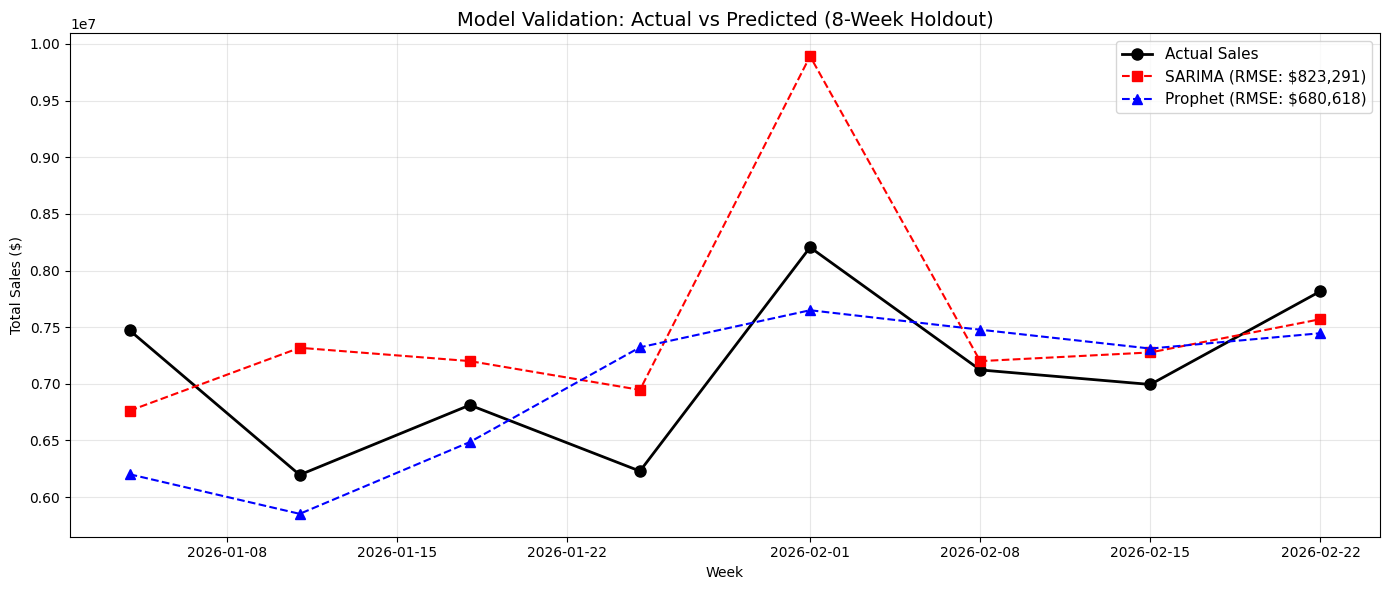

In [71]:
# RMSE Validation - Train/Test Split approach
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Split data: use last 8 weeks as test set, rest as training
test_size = 8
ts_train = ts[:-test_size]
ts_test = ts[-test_size:]

print(f"Training set: {len(ts_train)} weeks")
print(f"Test set: {len(ts_test)} weeks")
print(f"Test period: {ts_test.index[0].date()} to {ts_test.index[-1].date()}\n")

# --- SARIMA on training data ---
sarima_train = SARIMAX(
    ts_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
sarima_pred = sarima_train.get_forecast(steps=test_size).predicted_mean

# --- Prophet on training data ---
prophet_train_df = ts_train.reset_index()
prophet_train_df.columns = ['ds', 'y']
prophet_train_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
prophet_train_model.fit(prophet_train_df)
future_test = prophet_train_model.make_future_dataframe(periods=test_size, freq='W')
prophet_pred = prophet_train_model.predict(future_test).tail(test_size)

# --- Manual RMSE calculation (step by step) ---
actual = ts_test.values
sarima_predicted = sarima_pred.values
prophet_predicted = prophet_pred['yhat'].values

print("=== RMSE Manual Calculation (SARIMA) ===")
errors_sarima = actual - sarima_predicted
squared_errors = errors_sarima ** 2
mse = squared_errors.mean()
rmse_manual = np.sqrt(mse)

for i in range(len(actual)):
    print(f"  Week {i+1}: actual=${actual[i]:>12,.2f}  predicted=${sarima_predicted[i]:>12,.2f}  error=${errors_sarima[i]:>12,.2f}  error²=${squared_errors[i]:>16,.2f}")
print(f"\n  MSE  = {mse:,.2f}")
print(f"  RMSE = sqrt({mse:,.2f}) = ${rmse_manual:,.2f}")

# --- Compare both models ---
sarima_rmse = np.sqrt(mean_squared_error(actual, sarima_predicted))
prophet_rmse = np.sqrt(mean_squared_error(actual, prophet_predicted))
sarima_mae = mean_absolute_error(actual, sarima_predicted)
prophet_mae = mean_absolute_error(actual, prophet_predicted)

print(f"\n{'='*50}")
print(f"MODEL VALIDATION RESULTS ({test_size}-week holdout)")
print(f"{'='*50}")
print(f"{'Metric':<15} {'SARIMA':>15} {'Prophet':>15} {'Winner':>10}")
print(f"{'-'*55}")
print(f"{'RMSE':<15} ${sarima_rmse:>13,.2f} ${prophet_rmse:>13,.2f} {'SARIMA' if sarima_rmse < prophet_rmse else 'Prophet':>10}")
print(f"{'MAE':<15} ${sarima_mae:>13,.2f} ${prophet_mae:>13,.2f} {'SARIMA' if sarima_mae < prophet_mae else 'Prophet':>10}")
print(f"{'='*55}")

# Visualization: actual vs predicted
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ts_test.index, actual, 'ko-', label='Actual Sales', markersize=8, linewidth=2)
ax.plot(ts_test.index, sarima_predicted, 'rs--', label=f'SARIMA (RMSE: ${sarima_rmse:,.0f})', markersize=7)
ax.plot(ts_test.index, prophet_predicted, 'b^--', label=f'Prophet (RMSE: ${prophet_rmse:,.0f})', markersize=7)
ax.set_title(f'Model Validation: Actual vs Predicted ({test_size}-Week Holdout)', fontsize=14)
ax.set_ylabel('Total Sales ($)')
ax.set_xlabel('Week')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()